In [2]:
import numpy as np
import os
import cv2
import open3d as o3d
#import open3d.visualization.jupyter as o3d_jupyter
import pykitti
import torch
import threading
from ultralytics import YOLO
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import DBSCAN
from filterpy.kalman import KalmanFilter
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, recall_score
from collections import defaultdict

from matplotlib import cm

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
# Define KITTI Dataset Directory (Based on Your Structure)
BASE_DIR = "/home/umusa/JMODT/data/tracking"
TRAINING_DIR = f"{BASE_DIR}/training"
TESTING_DIR = f"{BASE_DIR}/testing"

In [4]:
def load_kitti_frame(frame_idx, sequence="0010", split="training"):
    """
    Load a KITTI frame (Camera + LiDAR) while handling subdirectories (0000 - 0020).
    
    Args:
    - frame_idx (int): The frame index (e.g., 10).
    - sequence (str): The subdirectory sequence (e.g., '0010').
    - split (str): 'training' or 'testing'.

    Returns:
    - img (numpy array): Loaded camera image.
    - lidar_data (numpy array): Loaded LiDAR point cloud (Nx3).
    """

    # Define base dataset directory
    #BASE_DIR = "/home/umusa/JMODT/data/tracking"
    DATA_DIR = f"{BASE_DIR}/{split}"

    # Construct correct file paths
    img_path = f"{DATA_DIR}/image_02/{sequence}/{str(frame_idx).zfill(6)}.png"
    lidar_path = f"{DATA_DIR}/velodyne/{sequence}/{str(frame_idx).zfill(6)}.bin"

    # Ensure files exist
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Camera image not found: {img_path}")
    if not os.path.exists(lidar_path):
        raise FileNotFoundError(f"LiDAR file not found: {lidar_path}")

    # Load Camera Image
    img = cv2.imread(img_path)

    # Load LiDAR Point Cloud
    lidar_data = np.fromfile(lidar_path, dtype=np.float32).reshape(-1, 4)[:, :3]  # Extract (x, y, z)

    return img, lidar_data

In [5]:
# --- KITTI Calibration Loader (Replaces earlier load_calibration) ---
def load_kitti_calib(calib_file_path):
    def parse_calib_line(line):
        return np.array([float(x) for x in line.strip().split()[1:]])

    calib = {}
    with open(calib_file_path, 'r') as f:
        for line in f:
            if line.startswith("P2:"):
                calib['P2'] = parse_calib_line(line).reshape(3, 4)
            elif line.startswith("R_rect"):
                calib['R0_rect'] = parse_calib_line(line).reshape(3, 3)
            elif line.startswith("Tr_velo_cam"):
                calib['Tr_velo_to_cam'] = parse_calib_line(line).reshape(3, 4)
    return calib


def build_projection_matrix(calib):
    P = calib['P2']
    R0 = np.eye(4)
    R0[:3, :3] = calib['R0_rect']
    Tr = np.eye(4)
    Tr[:3, :] = calib['Tr_velo_to_cam']
    return P @ R0 @ Tr  # T_mat


In [6]:
# -------------------- Convert LiDAR to Homogeneous --------------------
def bin2h_velo(lidar_points, remove_plane=True):
    lidar_points = lidar_points.T  # (3, N)
    velo_h = np.vstack((lidar_points, np.ones((1, lidar_points.shape[1]))))

    if remove_plane:
        ground_mask = velo_h[2, :] > -1.4  # z > -1.4
        velo_h = velo_h[:, ground_mask]

    return velo_h


# -------------------- LiDAR to Image Projection --------------------
def project_velo_to_image(velo_hom, calib):
    Tr = np.vstack((calib['Tr_velo_to_cam'], [0, 0, 0, 1]))  # (4x4)
    R0 = np.eye(4)
    R0[:3, :3] = calib['R0_rect']
    P = calib['P2']

    cam_coords = R0 @ Tr @ velo_hom  # (4, N)
    valid = cam_coords[2, :] > 0  # Only points in front of camera

    cam_coords = cam_coords[:, valid]
    img_pts = P @ cam_coords  # (3, N)
    img_pts = img_pts[:2, :] / cam_coords[2:3, :]  # Normalize to pixel

    return img_pts, cam_coords, valid





## LiDAR Clustering

In [7]:
def cluster_lidar(velo_hom):
    db = DBSCAN(eps=0.5, min_samples=30).fit(velo_hom[:3, :].T)
    return db, db.labels_

In [8]:
# -------------------- Cluster Projection to Image --------------------
def image_clusters_from_velo(velo_points, labels, calib):
    mask = labels != -1
    velo_filtered = velo_points[:, mask]
    labels = labels[mask]

    img_pts, _, valid = project_velo_to_image(velo_filtered, calib)
    labels = labels[valid]
    #img_pts = img_pts[:, valid]

    cam_clusters = {}
    for label in np.unique(labels):
        cluster_pts = img_pts[:, labels == label]
        if cluster_pts.shape[1] > 0:
            cam_clusters[label] = cluster_pts
    return cam_clusters

In [9]:
# --- LiDAR to Camera Projection (Replaces earlier project_lidar_to_camera) ---
def project_lidar_to_camera(lidar_points, calib):
    lidar_hom = np.hstack((lidar_points, np.ones((lidar_points.shape[0], 1))))
    Tr = np.vstack((calib['Tr_velo_to_cam'], [0, 0, 0, 1]))
    R0 = np.eye(4)
    R0[:3, :3] = calib['R0_rect']
    P = calib['P2']

    cam_points = (R0 @ Tr @ lidar_hom.T).T
    cam_points = cam_points[cam_points[:, 2] > 0]

    pts_2d = (P @ cam_points.T).T
    pts_2d = pts_2d[:, :2] / pts_2d[:, 2:3]

    return pts_2d, cam_points[:, :3]

In [10]:
# -------------------- Draw Clusters on Image --------------------
# def draw_clusters_on_image(image, cluster_dict, draw_centroids=False):
#     pastel = plt.colormaps.get_cmap('Pastel2')
#     get_pastel = lambda z: [int(255 * val) for val in pastel(int(z.round()))[:3]]

#     for label, cluster in cluster_dict.items():
#         for (u, v) in cluster.T:
#             if 0 <= int(u) < image.shape[1] and 0 <= int(v) < image.shape[0]:
#                 cv2.circle(image, (int(u), int(v)), 2, get_pastel(label), -1)

#         if draw_centroids:
#             centroid = np.mean(cluster, axis=1)
#             cv2.circle(image, (int(centroid[0]), int(centroid[1])), 6, get_pastel(label), -1)
#     return image


def draw_clusters_on_image(image, cluster_dict, draw_centroids=False):
    rainbow = plt.colormaps.get_cmap('rainbow')  # Use rainbow colormap
    get_color = lambda z: [int(255 * val) for val in rainbow(int(z.round()) % 256)[:3]]

    for label, cluster in cluster_dict.items():
        for (u, v) in cluster.T:
            if 0 <= int(u) < image.shape[1] and 0 <= int(v) < image.shape[0]:
                cv2.circle(image, (int(u), int(v)), 2, get_color(label), -1)

        if draw_centroids:
            centroid = np.mean(cluster, axis=1)
            cv2.circle(image, (int(centroid[0]), int(centroid[1])), 6, get_color(label), -1)

    return image


In [11]:
# -------------------- Open3D Visualization --------------------
def visualize_lidar_with_boxes(points, boxes=[]):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.paint_uniform_color([0.5, 0.5, 0.5])

    vis_elems = [pcd]
    for box in boxes:
        lines = [
            [0, 1], [1, 2], [2, 3], [3, 0],
            [4, 5], [5, 6], [6, 7], [7, 4],
            [0, 4], [1, 5], [2, 6], [3, 7]
        ]
        line_set = o3d.geometry.LineSet()
        line_set.points = o3d.utility.Vector3dVector(box)
        line_set.lines = o3d.utility.Vector2iVector(lines)
        line_set.paint_uniform_color([1, 0, 0])
        vis_elems.append(line_set)

    o3d.visualization.draw_geometries(vis_elems)

In [12]:
# --- Example usage of calibration + projection logic ---
sequence = "0012"
frame_idx = 12
split = "training"

In [13]:
# Load image and lidar
img, lidar = load_kitti_frame(frame_idx, sequence=sequence, split=split)

In [14]:
# Load calibration
calib_path = f"{BASE_DIR}/{split}/calib/{sequence}.txt"
calib = load_kitti_calib(calib_path)

In [15]:
# # Load data and calibration
# img, lidar = load_kitti_frame(frame_idx, sequence=sequence, split=split)
# calib_path = f"{BASE_DIR}/{split}/calib/{sequence}.txt"
# calib = load_kitti_calib(calib_path)

In [16]:
# Convert to homogeneous and remove ground
velo_hom = bin2h_velo(lidar, remove_plane=True)

In [17]:
# Perform DBSCAN clustering in 3D
dbscan = DBSCAN(eps=0.5, min_samples=30)
dbscan.fit(velo_hom[:3, :].T)
labels = dbscan.labels_

In [18]:
# Project clusters to image
clusters = image_clusters_from_velo(velo_hom, labels, calib)

In [19]:
# Draw clusters
output_img = draw_clusters_on_image(img.copy(), clusters, draw_centroids=True)

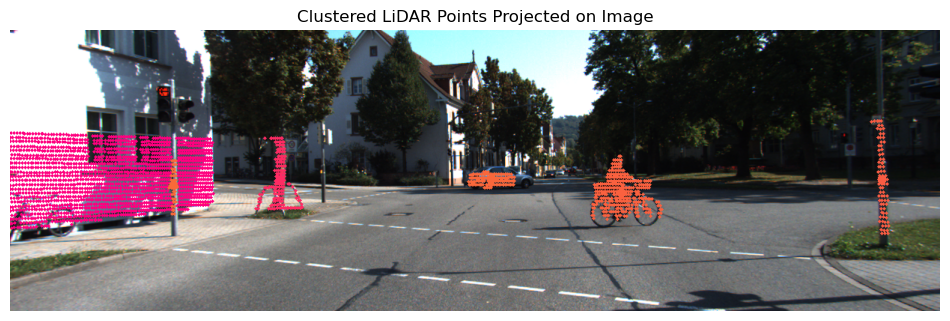

In [20]:
# Show 2D projection result
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.title("Clustered LiDAR Points Projected on Image")
plt.axis('off')
plt.show()

In [21]:
# def plot_projected_clusters_only(clusters, draw_centroids=False):
#     """
#     Plots clustered LiDAR points in image space (u, v) without background image.
#     """
#     pastel = plt.colormaps.get_cmap('rainbow')
#     get_color = lambda z: pastel(int(z.round()) % 256)

#     plt.figure(figsize=(12, 6))
#     ax = plt.gca()
#     ax.set_facecolor('white')

#     for label, cluster in clusters.items():
#         u, v = cluster[0, :], cluster[1, :]
#         plt.scatter(u, v, color=get_color(label), s=2)

#         if draw_centroids:
#             centroid = np.mean(cluster, axis=1)
#             plt.scatter(centroid[0], centroid[1], color=get_color(label), s=50, marker='x')

#     plt.title("Projected LiDAR Clusters (No Image Background)")
#     plt.xlabel("u (pixel)")
#     plt.ylabel("v (pixel)")
#     plt.gca().invert_yaxis()  # Because image origin is top-left
#     plt.grid(True)
#     plt.axis('equal')
#     plt.show()



In [22]:
#plot_projected_clusters_only(clusters, draw_centroids=True)

In [23]:
# Also visualize in 3D
_, cam_points = project_lidar_to_camera(lidar, calib)
visualize_lidar_with_boxes(cam_points)

## Displaying Clustered LiDAR Points Only in 3D

In [24]:
# def visualize_lidar_clusters_3d(velo_hom, labels):
#     """
#     Visualize LiDAR point cloud clusters in 3D using Open3D.
#     Each cluster gets a unique color.
#     """
#     import open3d as o3d
#     from matplotlib import cm

#     # Remove noise (-1 label)
#     mask = labels != -1
#     points = velo_hom[:3, mask].T
#     labels = labels[mask]

#     # Assign colors using a colormap
#     cmap = plt.colormaps.get_cmap('rainbow')
#     unique_labels = np.unique(labels)
#     colors = np.array([cmap(i / len(unique_labels))[:3] for i in labels])  # RGB

#     # Create Open3D point cloud
#     pcd = o3d.geometry.PointCloud()
#     pcd.points = o3d.utility.Vector3dVector(points)
#     pcd.colors = o3d.utility.Vector3dVector(colors)

#     o3d.visualization.draw_geometries([pcd])

In [25]:
# # Visualize clustered LiDAR in 3D (no camera image)
# visualize_lidar_clusters_3d(velo_hom, labels)

## Top-Down 2D Clustered LiDAR (X vs Y)

In [26]:
# def plot_lidar_clusters_topdown(velo_hom, labels):
#     """
#     2D top-down scatter plot of clustered LiDAR points (X vs Y).
#     """
#     mask = labels != -1
#     points = velo_hom[:3, mask]  # X, Y, Z
#     labels = labels[mask]

#     x = points[0, :]
#     y = points[1, :]
    
#     plt.figure(figsize=(10, 10))
#     scatter = plt.scatter(x, y, c=labels, cmap='rainbow', s=2)
#     plt.xlabel("X (Forward)")
#     plt.ylabel("Y (Left/Right)")
#     plt.title("Top-Down LiDAR Clusters (X vs Y)")
#     plt.axis('equal')
#     plt.grid(True)
#     plt.colorbar(scatter, label="Cluster ID")
#     plt.show()

In [27]:
# plot_lidar_clusters_topdown(velo_hom, labels)

## Front View (X vs Z)

In [28]:
# def plot_lidar_clusters_frontview(velo_hom, labels):
#     """
#     2D front-view scatter plot of clustered LiDAR points (X vs Z).
#     """
#     mask = labels != -1
#     points = velo_hom[:3, mask]
#     labels = labels[mask]

#     x = points[0, :]
#     z = points[2, :]
    
#     plt.figure(figsize=(10, 6))
#     scatter = plt.scatter(x, z, c=labels, cmap='rainbow', s=2)
#     plt.xlabel("X (Forward)")
#     plt.ylabel("Z (Height)")
#     plt.title("Front-View LiDAR Clusters (X vs Z)")
#     plt.grid(True)
#     plt.colorbar(scatter, label="Cluster ID")
#     plt.show()

In [29]:
# plot_lidar_clusters_frontview(velo_hom, labels)

## YOLOv8 Object Detection

In [30]:
from ultralytics import YOLO
yolo_model = YOLO("yolov8n.pt")

def detect_objects_camera(img):
    results = yolo_model(img)
    detections = []
    for r in results:
        boxes = r.boxes.xyxy.cpu().numpy()
        confs = r.boxes.conf.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy()
        labels = [yolo_model.names[int(cls)] for cls in classes]
        for bbox, conf, label in zip(boxes, confs, labels):
            x1, y1, x2, y2 = map(int, bbox)
            detections.append({
                'bbox': [x1, y1, x2, y2],
                'label': label,
                'conf': float(conf)
            })
    return detections


In [31]:
# LiDAR-Based Object Detection (DBSCAN Clustering)
def detect_objects_lidar(lidar_data):
    clustering = DBSCAN(eps=0.5, min_samples=5).fit(lidar_data)
    detected_objects = []
    for label in np.unique(clustering.labels_):
        if label != -1:
            points = lidar_data[clustering.labels_ == label]
            center = np.mean(points, axis=0)
            detected_objects.append(center)
    return detected_objects

## 3D Bounding Box Drawing

In [32]:
def get_3d_bbox_from_cluster(cluster_points):
    x_min, y_min, z_min = cluster_points.min(axis=1)
    x_max, y_max, z_max = cluster_points.max(axis=1)
    box_points = np.array([
        [x_max, y_max, z_max, 1],
        [x_max, y_max, z_min, 1],
        [x_max, y_min, z_max, 1],
        [x_max, y_min, z_min, 1],
        [x_min, y_max, z_max, 1],
        [x_min, y_max, z_min, 1],
        [x_min, y_min, z_max, 1],
        [x_min, y_min, z_min, 1]
    ]).T
    return box_points

In [33]:
def draw_3d_boxes(image, boxes_proj):
    pastel = plt.colormaps.get_cmap('Pastel2')
    get_color = lambda z: [int(255 * val) for val in pastel(z % 50)[:3]]

    for i, box in enumerate(boxes_proj):
        pts = box[:2, :].T.astype(int)
        if pts.shape[0] != 8:
            continue  # skip malformed boxes

        [A, B, C, D, E, F, G, H] = pts
        color = get_color(i)

        # Rear box
        cv2.line(image, tuple(A), tuple(B), color, 2)
        cv2.line(image, tuple(B), tuple(D), color, 2)
        cv2.line(image, tuple(D), tuple(C), color, 2)
        cv2.line(image, tuple(C), tuple(A), color, 2)

        # Front box
        cv2.line(image, tuple(G), tuple(E), color, 2)
        cv2.line(image, tuple(H), tuple(F), color, 2)
        cv2.line(image, tuple(G), tuple(H), color, 2)
        cv2.line(image, tuple(E), tuple(F), color, 2)

        # Sides
        cv2.line(image, tuple(E), tuple(A), color, 2)
        cv2.line(image, tuple(G), tuple(C), color, 2)
        cv2.line(image, tuple(F), tuple(B), color, 2)
        cv2.line(image, tuple(H), tuple(D), color, 2)

    return image



## Cluster ↔ Detection Matching (Fusion Logic)

In [34]:

def get_cluster_centroid_uvz(cluster):
    centroid = np.mean(cluster, axis=1)
    return centroid[[1, 0, 2]]  # (u, v, z)

def fuse_clusters_to_detections(clusters, detections, threshold=500):
    matched = {}
    for d in detections:
        x1, y1, x2, y2 = d['bbox']
        u_det = (x1 + x2) / 2
        v_det = (y1 + y2) / 2
        best_match = -1
        best_dist = float('inf')
        for label, cluster in clusters.items():
            uvz = get_cluster_centroid_uvz(cluster)
            dist = np.linalg.norm(uvz[:2] - [u_det, v_det])
            if dist < best_dist and dist < threshold:
                best_match = label
                best_dist = dist
        if best_match != -1:
            matched[best_match] = d
    return matched

## Main Fusion Pipeline (Per Frame)

In [35]:
def run_fusion_pipeline(frame_idx, sequence="0010", split="training"):
    img, lidar = load_kitti_frame(frame_idx, sequence, split)
    calib_path = f"{BASE_DIR}/{split}/calib/{sequence}.txt"
    calib = load_kitti_calib(calib_path)
    T_mat = build_projection_matrix(calib)

    velo_hom = bin2h_velo(lidar, remove_plane=True)
    db, labels = cluster_lidar(velo_hom)

    # Cluster projection
    clusters = {}
    for label in np.unique(labels):
        if label == -1: continue
        cluster = velo_hom[:, labels == label]
        img_pts, cam_coords, valid = project_velo_to_image(cluster, calib)
        if img_pts.shape[1] > 0:
            cluster_uvz = np.vstack((img_pts, cam_coords[2]))  # (3, N): u, v, z
            clusters[label] = cluster_uvz

    # Run YOLOv8 Detection
    detections = detect_objects_camera(img)

    # Match cluster → detection center
    matched = fuse_clusters_to_detections(clusters, detections)

    print(f"[Frame {frame_idx}] Matched {len(matched)} clusters to detections.")


    # Generate and draw 3D bounding boxes
    boxes_proj = []
    for label, det in matched.items():
        cluster = velo_hom[:, labels == label]
        bbox_3d = get_3d_bbox_from_cluster(cluster[:3, :])
        box_proj = T_mat @ bbox_3d
        box_proj[:2] /= box_proj[2:3]
        boxes_proj.append(box_proj)

    img = draw_3d_boxes(img, boxes_proj)
    return img, detections



## LiDAR Cluster Visualization

In [36]:
def plot_projected_clusters_black(clusters, draw_centroids=True):
    """
    Projects clustered LiDAR points into image space and displays them with a black background.
    """
    pastel = plt.colormaps.get_cmap('rainbow')
    get_color = lambda z: pastel(int(z.round()) % 256)

    plt.figure(figsize=(14, 7))
    ax = plt.gca()
    ax.set_facecolor('black')  # Match tutorial's background

    for label, cluster in clusters.items():
        u, v = cluster[0, :], cluster[1, :]
        plt.scatter(u, v, color=get_color(label), s=2)

        if draw_centroids:
            centroid = np.mean(cluster, axis=1)
            plt.scatter(centroid[0], centroid[1], color=get_color(label), s=25, marker='x')

    plt.gca().invert_yaxis()  # Image space: (0,0) is top-left
    plt.axis('equal')
    plt.axis('off')  # No axes
    plt.tight_layout()
    plt.title("Clustered LiDAR Points (Black Background)", color='white')
    plt.show()


In [37]:
#plot_projected_clusters_black(clusters)

## Object Tracking

In [38]:
from filterpy.kalman import KalmanFilter
import numpy as np

class KalmanBoxTracker:
    count = 0

    def __init__(self, bbox):
        self.kf = KalmanFilter(dim_x=7, dim_z=4)
        self.kf.F = np.array([[1, 0, 0, 0, 1, 0, 0],
                              [0, 1, 0, 0, 0, 1, 0],
                              [0, 0, 1, 0, 0, 0, 1],
                              [0, 0, 0, 1, 0, 0, 0],
                              [0, 0, 0, 0, 1, 0, 0],
                              [0, 0, 0, 0, 0, 1, 0],
                              [0, 0, 0, 0, 0, 0, 1]])
        self.kf.H = np.array([[1, 0, 0, 0, 0, 0, 0],
                              [0, 1, 0, 0, 0, 0, 0],
                              [0, 0, 1, 0, 0, 0, 0],
                              [0, 0, 0, 1, 0, 0, 0]])

        self.kf.R *= 10
        self.kf.P *= 10
        self.kf.Q *= 0.01

        self.kf.x[:4] = np.array(self.convert_bbox_to_z(bbox)).reshape((4, 1))

        self.id = KalmanBoxTracker.count
        KalmanBoxTracker.count += 1
        self.hits = 0
        self.no_losses = 0
        self.confirmed = False

    def update(self, bbox):
        z = np.array(self.convert_bbox_to_z(bbox)).reshape((4, 1))
        self.kf.update(z)
        self.hits += 1
        self.no_losses = 0
        if self.hits >= 3:
            self.confirmed = True

    def predict(self):
        self.kf.predict()
        self.no_losses += 1
        return self.kf.x

    def get_state(self):
        return self.convert_x_to_bbox(self.kf.x)

    def convert_bbox_to_z(self, bbox):
        x1, y1, x2, y2 = bbox
        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0
        s = (x2 - x1) * (y2 - y1)
        r = (x2 - x1) / (y2 - y1 + 1e-6)
        return [cx, cy, s, r]

    def convert_x_to_bbox(self, x):
        cx, cy, s, r = x[:4].flatten()
        w = np.sqrt(s * r)
        h = s / (w + 1e-6)
        x1 = cx - w / 2
        y1 = cy - h / 2
        x2 = cx + w / 2
        y2 = cy + h / 2
        return [int(x1), int(y1), int(x2), int(y2)]


# from filterpy.kalman import KalmanFilter
# import numpy as np

# class KalmanBoxTracker:
#     count = 0

#     def __init__(self, bbox):
#         """
#         Initializes a tracker using initial bounding box [x1, y1, x2, y2].
#         """
#         self.kf = KalmanFilter(dim_x=7, dim_z=4)
#         self.kf.F = np.array([[1,0,0,0,1,0,0],
#                               [0,1,0,0,0,1,0],
#                               [0,0,1,0,0,0,1],
#                               [0,0,0,1,0,0,0],
#                               [0,0,0,0,1,0,0],
#                               [0,0,0,0,0,1,0],
#                               [0,0,0,0,0,0,1]])

#         self.kf.H = np.array([[1,0,0,0,0,0,0],
#                               [0,1,0,0,0,0,0],
#                               [0,0,1,0,0,0,0],
#                               [0,0,0,1,0,0,0]])

#         self.kf.R *= 10
#         self.kf.P *= 10
#         self.kf.Q *= 0.01

#         x1, y1, x2, y2 = bbox
#         cx, cy, s, r = self.convert_bbox_to_z(bbox)
#         self.kf.x[:4] = np.array([cx, cy, s, r]).reshape((4, 1))

#         self.id = KalmanBoxTracker.count
#         KalmanBoxTracker.count += 1
#         self.hits = 0
#         self.no_losses = 0

#     def update(self, bbox):
#         z = np.array(self.convert_bbox_to_z(bbox)).reshape((4, 1))
#         self.kf.update(z)
#         self.hits += 1
#         self.no_losses = 0

#     def predict(self):
#         self.kf.predict()
#         self.no_losses += 1
#         return self.kf.x

#     def get_state(self):
#         return self.convert_x_to_bbox(self.kf.x)

#     def convert_bbox_to_z(self, bbox):
#         x1, y1, x2, y2 = bbox
#         cx = (x1 + x2) / 2.0
#         cy = (y1 + y2) / 2.0
#         s = (x2 - x1) * (y2 - y1)  # scale is area
#         r = (x2 - x1) / (y2 - y1 + 1e-6)  # avoid divide-by-zero
#         return [cx, cy, s, r]

#     def convert_x_to_bbox(self, x):
#         cx, cy, s, r = x[:4].flatten()
#         w = np.sqrt(s * r)
#         h = s / (w + 1e-6)
#         x1 = cx - w / 2
#         y1 = cy - h / 2
#         x2 = cx + w / 2
#         y2 = cy + h / 2
#         return [int(x1), int(y1), int(x2), int(y2)]


# from filterpy.kalman import KalmanFilter

# def create_kf(center):
#     kf = KalmanFilter(dim_x=4, dim_z=2)
    
#     # Initial state: [x, y, dx, dy]
#     kf.x = np.array([center[0], center[1], 0, 0]).reshape((4, 1))
    
#     # State transition matrix (constant velocity model)
#     kf.F = np.array([[1, 0, 1, 0],
#                      [0, 1, 0, 1],
#                      [0, 0, 1, 0],
#                      [0, 0, 0, 1]])
    
#     # Measurement function
#     kf.H = np.array([[1, 0, 0, 0],
#                      [0, 1, 0, 0]])
    
#     # Initial uncertainty
#     kf.P *= 10.
    
#     # Measurement uncertainty
#     kf.R *= 5.
    
#     # Process noise
#     kf.Q = np.eye(4)
    
#     return kf



In [39]:
from scipy.spatial import distance
from collections import defaultdict

class TrackerManager:
    def __init__(self, max_age=5, min_hits=3):
        self.trackers = []
        self.max_age = max_age
        self.min_hits = min_hits

    def update(self, detections):
        results = []

        # Step 1: Predict all trackers
        for tracker in self.trackers:
            tracker.predict()

        matched_trackers = set()

        # Step 2: Assign detections using Mahalanobis distance
        for det in detections:
            x1, y1, x2, y2 = det['bbox']
            best_dist = float('inf')
            best_tracker = None

            for tracker in self.trackers:
                z = np.array(tracker.convert_bbox_to_z(det['bbox'])).reshape((4, 1))
                y = z - tracker.kf.H @ tracker.kf.x
                S = tracker.kf.H @ tracker.kf.P @ tracker.kf.H.T + tracker.kf.R
                dist = np.sqrt(y.T @ np.linalg.inv(S) @ y)
                if dist < best_dist and dist < 9.487:
                    best_dist = dist
                    best_tracker = tracker

            if best_tracker:
                best_tracker.update(det['bbox'])
                det['id'] = best_tracker.id
                results.append(det)
                matched_trackers.add(best_tracker)
            else:
                new_tracker = KalmanBoxTracker(det['bbox'])
                new_tracker.update(det['bbox'])  # First update
                det['id'] = new_tracker.id
                self.trackers.append(new_tracker)
                results.append(det)
                matched_trackers.add(new_tracker)

        # Step 3: Clean up unmatched trackers
        for tracker in self.trackers:
            if tracker not in matched_trackers:
                tracker.no_losses += 1

        self.trackers = [t for t in self.trackers if t.no_losses <= self.max_age]
        return results


# class TrackerManager:
#     def __init__(self, max_age=5, min_hits=3):
#         self.trackers = []
#         self.max_age = max_age
#         self.min_hits = min_hits

#     def update(self, detections):
#         results = []

#         # Predict
#         for tracker in self.trackers:
#             tracker.predict()

#         matched_trackers = set()

#         for det in detections:
#             x1, y1, x2, y2 = det['bbox']
#             best_dist = float('inf')
#             best_tracker = None

#             for tracker in self.trackers:
#                 if tracker.confirmed:
#                     z = np.array(tracker.convert_bbox_to_z(det['bbox'])).reshape((4, 1))
#                     y = z - tracker.kf.H @ tracker.kf.x
#                     S = tracker.kf.H @ tracker.kf.P @ tracker.kf.H.T + tracker.kf.R
#                     dist = np.sqrt(y.T @ np.linalg.inv(S) @ y)
#                     if dist < best_dist and dist < 9.487:
#                         best_dist = dist
#                         best_tracker = tracker

#             if best_tracker:
#                 best_tracker.update(det['bbox'])
#                 det['id'] = best_tracker.id
#                 results.append(det)
#                 matched_trackers.add(best_tracker)
#             else:
#                 new_tracker = KalmanBoxTracker(det['bbox'])
#                 new_tracker.update(det['bbox'])  # First update
#                 self.trackers.append(new_tracker)
#                 if new_tracker.confirmed:
#                     det['id'] = new_tracker.id
#                     results.append(det)
#                     matched_trackers.add(new_tracker)

#         # Clean up
#         for tracker in self.trackers:
#             if tracker not in matched_trackers:
#                 tracker.no_losses += 1

#         self.trackers = [t for t in self.trackers if t.no_losses <= self.max_age]

#         return results

# class TrackerManager:
#     def __init__(self, max_age=5, min_hits=3):
#         self.trackers = []
#         self.max_age = max_age
#         self.min_hits = min_hits

#     def update(self, detections):
#         matched_trackers = []
#         results = []

#         # Predict all trackers
#         for tracker in self.trackers:
#             tracker.predict()

#         # Associate detections using Mahalanobis distance
#         for det in detections:
#             x1, y1, x2, y2 = det['bbox']
#             best_dist = float('inf')
#             best_tracker = None
#             for tracker in self.trackers:
#                 dist = self.mahalanobis_dist(tracker, det)
#                 if dist < best_dist:
#                     best_dist = dist
#                     best_tracker = tracker

#             # Chi-squared 95% threshold for 4 DOF = 9.487
#             if best_dist < 9.487:
#                 best_tracker.update(det['bbox'])
#                 best_tracker.hits += 1
#                 best_tracker.no_losses = 0

#                 if best_tracker.hits >= self.min_hits:
#                     best_tracker.confirmed = True
#                     det['id'] = best_tracker.id
#                     matched_trackers.append(best_tracker)
#                     results.append(det)
#             else:
#                 new_tracker = KalmanBoxTracker(det['bbox'])
#                 self.trackers.append(new_tracker)

#                 if new_tracker.hits >= self.min_hits:
#                     new_tracker.confirmed = True
#                     det['id'] = new_tracker.id
#                     matched_trackers.append(new_tracker)
#                     results.append(det)

#         # Age unmatched trackers
#         for tracker in self.trackers:
#             if tracker not in matched_trackers:
#                 tracker.no_losses += 1

#         # Remove stale trackers
#         self.trackers = [t for t in self.trackers if t.no_losses <= self.max_age]

#         return {
#             det['id']: (
#                 (det['bbox'][0] + det['bbox'][2]) / 2,
#                 (det['bbox'][1] + det['bbox'][3]) / 2
#             ) for det in results
#         }

    def mahalanobis_dist(self, tracker, det):
        z = np.array(tracker.convert_bbox_to_z(det['bbox'])).reshape((4, 1))
        y = z - tracker.kf.H @ tracker.kf.x
        S = tracker.kf.H @ tracker.kf.P @ tracker.kf.H.T + tracker.kf.R
        return np.sqrt(y.T @ np.linalg.inv(S) @ y)





# class TrackerManager:
#     def __init__(self, dist_thresh=50, max_missed=5):
#         self.trackers = {}  # track_id: {'kf': KalmanFilter, 'missed': int}
#         self.next_id = 0
#         self.dist_thresh = dist_thresh
#         self.max_missed = max_missed

#     def update(self, detections):
#         results = {}

#         # Predict all trackers
#         for track_id, tracker in self.trackers.items():
#             tracker['kf'].predict()
#             tracker['missed'] += 1

#         matched = set()

#         # Associate detections to trackers using center-distance
#         for det in detections:
#             cx, cy = det  # detections are (cx, cy) tuples

#             best_dist = float('inf')
#             best_id = None
#             for track_id, tracker in self.trackers.items():
#                 pred = tracker['kf'].x[:2].flatten()
#                 dist = np.linalg.norm([cx - pred[0], cy - pred[1]])
#                 if dist < best_dist and dist < self.dist_thresh:
#                     best_dist = dist
#                     best_id = track_id

#             if best_id is not None:
#                 self.trackers[best_id]['kf'].update([cx, cy])
#                 self.trackers[best_id]['missed'] = 0
#                 results[best_id] = (cx, cy)
#                 matched.add(best_id)
#             else:
#                 self.trackers[self.next_id] = {
#                     'kf': create_kf((cx, cy)),
#                     'missed': 0
#                 }
#                 results[self.next_id] = (cx, cy)
#                 self.next_id += 1

#         # Remove stale trackers
#         to_remove = [tid for tid, t in self.trackers.items() if t['missed'] > self.max_missed]
#         for tid in to_remove:
#             del self.trackers[tid]

#         return results


# class TrackerManager:
#     def __init__(self, max_age=5, min_hits=3):
#         self.trackers = []
#         self.max_age = max_age
#         self.min_hits = min_hits

#     def update(self, detections):
#         updated_detections = []

#         # Step 1: Predict all trackers
#         for tracker in self.trackers:
#             tracker.predict()

#         # Step 2: Associate detections with trackers based on IoU
#         unmatched_dets = []
#         for det in detections:
#             x1, y1, x2, y2 = det['bbox']
#             best_iou = 0
#             best_tracker = None
#             for tracker in self.trackers:
#                 iou = self.compute_iou(det['bbox'], tracker.get_state())
#                 if iou > best_iou:
#                     best_iou = iou
#                     best_tracker = tracker

#             if best_iou > 0.3:  # IoU threshold
#                 best_tracker.update(det['bbox'])
#                 det['id'] = best_tracker.id
#                 updated_detections.append(det)
#             else:
#                 unmatched_dets.append(det)

#         # Step 3: Create new trackers for unmatched detections
#         for det in unmatched_dets:
#             new_tracker = KalmanBoxTracker(det['bbox'])
#             self.trackers.append(new_tracker)
#             det['id'] = new_tracker.id
#             updated_detections.append(det)

#         # Step 4: Remove stale trackers
#         self.trackers = [t for t in self.trackers if t.no_losses <= self.max_age]

#         return updated_detections

#     def compute_iou(self, boxA, boxB):
#         xA = max(boxA[0], boxB[0])
#         yA = max(boxA[1], boxB[1])
#         xB = min(boxA[2], boxB[2])
#         yB = min(boxA[3], boxB[3])

#         interArea = max(0, xB - xA) * max(0, yB - yA)
#         boxAArea = max(1.0, (boxA[2] - boxA[0]) * (boxA[3] - boxA[1]))
#         boxBArea = max(1.0, (boxB[2] - boxB[0]) * (boxB[3] - boxB[1]))

#         iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
#         return iou




## Affinity Computation and Data Association

In [40]:
# from scipy.optimize import linear_sum_assignment

# # Compute Affinity (IoU + 3D Distance)
# def compute_affinity_matrix(tracked_objects, detections):
#     affinity_matrix = np.zeros((len(tracked_objects), len(detections)))

#     for i, track in enumerate(tracked_objects.values()):
#         for j, detection in enumerate(detections):
#             # iou_score = np.exp(-np.linalg.norm(track['position'] - detection))
#             # affinity_matrix[i, j] = iou_score

#             # Use a weighted combination of IoU and Euclidean distance
#             distance_score = np.exp(-np.linalg.norm(track['position'] - detection))
#             affinity_matrix[i, j] = distance_score  # Keep it in range [0,1]


#     return affinity_matrix

# # Data Association (Hungarian Algorithm)
# def data_association(affinity_matrix):
#     cost_matrix = 1 - affinity_matrix  
#     row_ind, col_ind = linear_sum_assignment(cost_matrix)
#     return list(zip(row_ind, col_ind))


# from scipy.optimize import linear_sum_assignment

# def compute_affinity_matrix_kalman(trackers, detections):
#     affinity_matrix = np.zeros((len(trackers), len(detections)))

#     for i, (_, tracker) in enumerate(trackers.items()):
#         track_pos = tracker['kf'].x[:2].flatten()
#         for j, det in enumerate(detections):
#             det_center = np.array([(det['bbox'][0] + det['bbox'][2]) / 2,
#                                    (det['bbox'][1] + det['bbox'][3]) / 2])
#             dist = np.linalg.norm(track_pos - det_center)
#             affinity_matrix[i, j] = np.exp(-dist / 100.0)  # Adjustable scaling
#     return affinity_matrix

# def associate_detections(affinity_matrix, threshold=0.3):
#     cost_matrix = 1 - affinity_matrix
#     row_ind, col_ind = linear_sum_assignment(cost_matrix)
#     matches = []
#     for r, c in zip(row_ind, col_ind):
#         if affinity_matrix[r, c] > threshold:
#             matches.append((r, c))
#     return matches


## YOLOv8 Tracking per Frame

# Using this cell to integrate with your Kalman + Hungarian logic

In [41]:
# def track_objects_fusion(num_frames=50, sequence="0010", split="training"):
#     tracked_objects = {}
#     pred_tracks = defaultdict(list)

#     for frame_idx in range(num_frames):
#         print(f"\n🔹 Frame {frame_idx}")
#         img, detections = run_fusion_pipeline(frame_idx, sequence, split)

#         # Optional draw YOLO detections
#         for obj in detections:
#             x1, y1, x2, y2 = obj['bbox']
#             label = obj['label']
#             conf = obj['conf']
#             pred_tracks[frame_idx].append({'id': obj.get('id', -1), 'bbox': [x1, y1, x2, y2]})
#             #cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
#             cv2.putText(img, f"{label} {conf:.2f}", (x1, y1 - 5),
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)

#         # Run tracking (simplified logic reused from your Kalman-based block)
#         # You can plug in compute_affinity_matrix(), data_association(), etc. here as-is

#         # Show image
#         cv2.imshow("Fusion Tracking", img)
#         if cv2.waitKey(1) == 27:
#             break

#     cv2.destroyAllWindows()
#     return pred_tracks


# def track_objects_fusion(num_frames=50, sequence="0010", split="training", save_video=True):
#     tracked_objects = {}
#     pred_tracks = defaultdict(list)

#     if save_video:
#         video_writer = cv2.VideoWriter("fusion_tracking_output.mp4",
#                                        cv2.VideoWriter_fourcc(*'mp4v'),
#                                        10,  # FPS
#                                        (640, 224))  # Adjust this to your image shape

#     for frame_idx in range(num_frames):
#         print(f"\n🔹 Frame {frame_idx}")
#         img, detections = run_fusion_pipeline(frame_idx, sequence, split)

#         # Assign unique IDs (dummy tracking for now)
#         for i, obj in enumerate(detections):
#             x1, y1, x2, y2 = obj['bbox']
#             label = obj['label']
#             conf = obj['conf']
#             obj_id = i  # Replace with proper tracker ID logic if needed

#             # Draw 2D bbox with label + confidence
#             cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
#             cv2.putText(img, f"{label} {conf:.2f}", (x1, y1 - 10),
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

#             # Draw track ID
#             cv2.putText(img, f"ID:{obj_id}", (x1, y2 + 15),
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

#             # Save to predictions
#             pred_tracks[frame_idx].append({'id': obj_id, 'bbox': [x1, y1, x2, y2]})

#         # Already drawn 3D boxes in run_fusion_pipeline()
#         # If needed again, you can call: img = draw_3d_boxes(img, boxes_proj)

#         # Show and/or Save
#         cv2.imshow("Fusion Tracking", img)
#         if save_video:
#             video_writer.write(img)

#         if cv2.waitKey(1) == 27:
#             break

#     if save_video:
#         video_writer.release()
#     cv2.destroyAllWindows()
#     return pred_tracks


# def track_objects_kalman(num_frames=100, sequence="0010", split="training"):
#     next_id = 0
#     tracked_objects = {}  # id: {'kf': KalmanFilter, 'missed': int}
#     pred_tracks = defaultdict(list)

#     for frame_idx in range(num_frames):
#         print(f"\n🔹 Frame {frame_idx}")
#         img, detections = run_fusion_pipeline(frame_idx, sequence, split)

#         # Predict
#         for obj in tracked_objects.values():
#             obj['kf'].predict()

#         # Compute affinity matrix and associate
#         affinity = compute_affinity_matrix_kalman(tracked_objects, detections)
#         matches = associate_detections(affinity)

#         # Update matched
#         matched_det = set()
#         matched_ids = set()
#         for track_idx, det_idx in matches:
#             track_id = list(tracked_objects.keys())[track_idx]
#             detection = detections[det_idx]
#             det_center = [(detection['bbox'][0] + detection['bbox'][2]) / 2,
#                           (detection['bbox'][1] + detection['bbox'][3]) / 2]
#             tracked_objects[track_id]['kf'].update(det_center)
#             tracked_objects[track_id]['missed'] = 0
#             detection['id'] = track_id
#             pred_tracks[frame_idx].append({'id': track_id, 'bbox': detection['bbox']})
#             matched_det.add(det_idx)
#             matched_ids.add(track_id)

#         # Add unmatched detections as new trackers
#         for idx, det in enumerate(detections):
#             if idx in matched_det:
#                 continue
#             center = [(det['bbox'][0] + det['bbox'][2]) / 2,
#                       (det['bbox'][1] + det['bbox'][3]) / 2]
#             kf = create_kf(center)
#             tracked_objects[next_id] = {'kf': kf, 'missed': 0}
#             det['id'] = next_id
#             pred_tracks[frame_idx].append({'id': next_id, 'bbox': det['bbox']})
#             next_id += 1

#         # Remove stale tracks
#         remove_ids = []
#         for obj_id, obj in tracked_objects.items():
#             if obj_id in matched_ids:
#                 continue
#             obj['missed'] += 1
#             if obj['missed'] > 5:
#                 remove_ids.append(obj_id)
#         for rid in remove_ids:
#             del tracked_objects[rid]

#         # Visualize
#         for det in detections:
#             x1, y1, x2, y2 = det['bbox']
#             cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
#             cv2.putText(img, f"ID {det['id']}", (x1, y1 - 8),
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

#         cv2.imshow("Kalman Tracking", img)
#         if cv2.waitKey(1) == 27:
#             break

#     cv2.destroyAllWindows()
#     return pred_tracks


# def track_objects_with_tracker_manager(num_frames=100, sequence="0010", split="training"):
#     tracker = TrackerManager()  # handles Kalman + ID management
#     pred_tracks = defaultdict(list)

#     for frame_idx in range(num_frames):
#         print(f"\n🔹 Frame {frame_idx}")
#         img, detections = run_fusion_pipeline(frame_idx, sequence, split)

#         # Get bounding box centers from detections
#         det_centers = []
#         for det in detections:
#             x1, y1, x2, y2 = det['bbox']
#             cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
#             det_centers.append((cx, cy))

#         # Perform update using TrackerManager
#         tracked_dets = tracker.update(detections)

#         # # Assign IDs back to detections for visualization
#         # for i, (track_id, (cx, cy)) in enumerate(tracked_dets.items()):
#         #     if i < len(detections):
#         #         detections[i]['id'] = track_id
#         #         pred_tracks[frame_idx].append({'id': track_id, 'bbox': detections[i]['bbox']})
#         #         x1, y1, x2, y2 = detections[i]['bbox']
#         #         cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
#         #         cv2.putText(img, f"ID {track_id}", (x1, y1 - 8),
#         #                     cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)


#         # Assign IDs back to detections for visualization
#         for det in tracked_dets:
#             track_id = det['id']
#             pred_tracks[frame_idx].append({'id': track_id, 'bbox': det['bbox']})
#             x1, y1, x2, y2 = det['bbox']
#             cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
#             cv2.putText(img, f"ID {track_id}", (x1, y1 - 8),
#                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

#         # Show frame
#         cv2.imshow("Kalman Tracking with Manager", img)
#         if cv2.waitKey(1) == 27:
#             break

#     cv2.destroyAllWindows()
#     return pred_tracks



def track_objects_with_tracker_manager(num_frames=100, sequence="0010", split="training"):
    tracker = TrackerManager()  # handles Kalman + ID management
    pred_tracks = defaultdict(list)

    # Initialize video writer
    initialized = False
    video_writer = None

    for frame_idx in range(num_frames):
        print(f"\n🔹 Frame {frame_idx}")
        img, detections = run_fusion_pipeline(frame_idx, sequence, split)

        # Initialize video writer once (after getting image shape)
        if not initialized:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            video_writer = cv2.VideoWriter("tracking_output.mp4", fourcc, 15, (img.shape[1], img.shape[0]))
            initialized = True

        # Get bounding box centers from detections
        det_centers = []
        for det in detections:
            x1, y1, x2, y2 = det['bbox']
            cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
            det_centers.append((cx, cy))

        # Perform update using TrackerManager
        tracked_dets = tracker.update(detections)

        # Assign IDs back to detections for visualization
        for det in tracked_dets:
            track_id = det['id']
            pred_tracks[frame_idx].append({'id': track_id, 'bbox': det['bbox']})
            x1, y1, x2, y2 = det['bbox']
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(img, f"ID {track_id}", (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

        # Write frame to video
        video_writer.write(img)

        # Show frame
        cv2.imshow("Kalman Tracking with Manager", img)
        if cv2.waitKey(1) == 27:
            break

    # Clean up
    cv2.destroyAllWindows()
    if video_writer is not None:
        video_writer.release()

    return pred_tracks





## Tracking Pipeline

In [42]:
# Load Ground Truth for Evaluation

def load_kitti_ground_truth(label_dir, sequence):
    label_file = os.path.join(label_dir, f"{sequence}.txt")
    gt_tracks = defaultdict(list)
    with open(label_file, 'r') as f:
        for line in f.readlines():
            fields = line.strip().split()
            frame_id = int(fields[0])
            obj_id = int(fields[1])
            obj_type = fields[2]
            if obj_type != 'Car':
                continue
            bbox = list(map(float, fields[6:10]))
            gt_tracks[frame_id].append({'id': obj_id, 'bbox': bbox})
    return gt_tracks

## Evaluation Metrics

In [43]:
import numpy as np
from sklearn.metrics import f1_score, recall_score
from scipy.optimize import linear_sum_assignment
from collections import defaultdict

# IOU Function
def iou(bbox1, bbox2):
    x1, y1, x2, y2 = bbox1
    x1g, y1g, x2g, y2g = bbox2
    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)
    inter_area = max(xi2 - xi1, 0) * max(yi2 - yi1, 0)
    bbox1_area = (x2 - x1) * (y2 - y1)
    bbox2_area = (x2g - x1g) * (y2g - y1g)
    union_area = bbox1_area + bbox2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

# Multi-Object Tracking Metrics
def compute_mot_metrics(gt_tracks, pred_tracks, iou_threshold=0.5):
    mota_fn = 0   # False Negatives
    mota_fp = 0   # False Positives
    mota_idsw = 0 # Identity Switches
    mota_total_gt = 0
    motp_sum = 0
    motp_matches = 0
    recall_list = []
    f1_list = []

    for frame_id in sorted(gt_tracks.keys()):
        gt = gt_tracks[frame_id]
        pred = pred_tracks.get(frame_id, [])
        if not gt and not pred:
            continue

        iou_matrix = np.zeros((len(gt), len(pred)))
        for i, g in enumerate(gt):
            for j, p in enumerate(pred):
                iou_matrix[i, j] = iou(g['bbox'], p['bbox'])

        row_ind, col_ind = linear_sum_assignment(-iou_matrix)
        matched_gt = set()
        matched_pred = set()
        for i, j in zip(row_ind, col_ind):
            if iou_matrix[i, j] >= iou_threshold:
                matched_gt.add(i)
                matched_pred.add(j)
                motp_sum += iou_matrix[i, j]
                motp_matches += 1
                if gt[i]['id'] != pred[j]['id']:
                    mota_idsw += 1

        fn = len(gt) - len(matched_gt)
        fp = len(pred) - len(matched_pred)
        mota_fn += fn
        mota_fp += fp
        mota_total_gt += len(gt)

        y_true = [1] * len(gt)
        y_pred = [1 if j in matched_pred else 0 for j in range(len(pred))]
        if len(y_true) == len(y_pred):
            recall_list.append(recall_score(y_true, y_pred, zero_division=0))
            f1_list.append(f1_score(y_true, y_pred, zero_division=0))

    mota = 1 - (mota_fn + mota_fp + mota_idsw) / mota_total_gt if mota_total_gt else 1
    motp = motp_sum / motp_matches if motp_matches else 0
    recall_avg = np.mean(recall_list)
    f1_avg = np.mean(f1_list)
    amota = mota  # For now, AMOTA is approximated as average MOTA
    amotp = motp  # For now, AMOTP is approximated as average MOTP
    return mota, motp, amota, amotp, recall_avg, f1_avg

# Higher Order Tracking Accuracy (HOTA)
def compute_hota(gt_tracks, pred_tracks, thresholds=np.linspace(0.05, 0.95, 19)):
    hota_scores = []

    for alpha in thresholds:
        TP = 0
        TPA = 0
        FPA = 0
        FNA = 0

        for frame_id in sorted(gt_tracks.keys()):
            gt = gt_tracks[frame_id]
            pred = pred_tracks.get(frame_id, [])
            
            matched = 0  # Reset matched for this frame

            if gt and pred:
                iou_matrix = np.zeros((len(gt), len(pred)))
                for i, g in enumerate(gt):
                    for j, p in enumerate(pred):
                        iou_matrix[i, j] = iou(g['bbox'], p['bbox'])

                row_ind, col_ind = linear_sum_assignment(-iou_matrix)

                for i, j in zip(row_ind, col_ind):
                    if iou_matrix[i, j] >= alpha:
                        matched += 1
                        TP += 1
                        if gt[i]['id'] == pred[j]['id']:
                            TPA += 1
                        else:
                            FPA += 1
                            FNA += 1

            FN = len(gt) - matched
            FP = len(pred) - matched

        DetA = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
        AssA = TPA / (TPA + FPA + FNA) if (TPA + FPA + FNA) > 0 else 0

        if TP > 0:
            hota_scores.append(np.sqrt(DetA * AssA))

    return np.mean(hota_scores) if hota_scores else 0

# Evaluation Block (call after running tracking)
def evaluate_metrics(gt_tracks, pred_tracks):
    mota, motp, amota, amotp, recall, f1 = compute_mot_metrics(gt_tracks, pred_tracks)
    hota_score = compute_hota(gt_tracks, pred_tracks)

    print("\n✅ Final Tracking Evaluation Metrics:")
    print(f"MOTA:  {mota:.4f}  (Multi-Object Tracking Accuracy)")
    print(f"MOTP:  {motp:.4f}  (Multi-Object Tracking Precision)")
    print(f"AMOTA: {amota:.4f}  (Average MOTA over sequence)")
    print(f"AMOTP: {amotp:.4f}  (Average MOTP over sequence)")
    print(f"Recall:{recall:.4f}")
    print(f"F1:    {f1:.4f}")
    print(f"HOTA:  {hota_score:.4f}  (Higher Order Tracking Accuracy)")

In [44]:
# Run tracking
pred_tracks = track_objects_with_tracker_manager(num_frames=100)


🔹 Frame 0

0: 224x640 5 cars, 50.6ms
Speed: 6.7ms preprocess, 50.6ms inference, 118.9ms postprocess per image at shape (1, 3, 224, 640)
[Frame 0] Matched 2 clusters to detections.

🔹 Frame 1

0: 224x640 3 cars, 4.9ms
Speed: 1.0ms preprocess, 4.9ms inference, 0.9ms postprocess per image at shape (1, 3, 224, 640)
[Frame 1] Matched 1 clusters to detections.

🔹 Frame 2

0: 224x640 3 cars, 14.9ms
Speed: 2.4ms preprocess, 14.9ms inference, 1.8ms postprocess per image at shape (1, 3, 224, 640)
[Frame 2] Matched 1 clusters to detections.

🔹 Frame 3

0: 224x640 1 person, 3 cars, 4.8ms
Speed: 1.0ms preprocess, 4.8ms inference, 0.9ms postprocess per image at shape (1, 3, 224, 640)
[Frame 3] Matched 1 clusters to detections.

🔹 Frame 4

0: 224x640 3 cars, 5.5ms
Speed: 1.0ms preprocess, 5.5ms inference, 0.9ms postprocess per image at shape (1, 3, 224, 640)
[Frame 4] Matched 1 clusters to detections.

🔹 Frame 5

0: 224x640 4 cars, 5.6ms
Speed: 1.1ms preprocess, 5.6ms inference, 1.3ms postprocess pe

In [45]:
# Load ground truth
label_dir = f"{TRAINING_DIR}/label_02"
gt_tracks = load_kitti_ground_truth(label_dir, "0010")

In [46]:
# ✅ Evaluation Block
evaluate_metrics(gt_tracks, pred_tracks)


✅ Final Tracking Evaluation Metrics:
MOTA:  -0.1161  (Multi-Object Tracking Accuracy)
MOTP:  0.8877  (Multi-Object Tracking Precision)
AMOTA: -0.1161  (Average MOTA over sequence)
AMOTP: 0.8877  (Average MOTP over sequence)
Recall:0.9568
F1:    0.9691
HOTA:  0.0773  (Higher Order Tracking Accuracy)


## Save Video

In [47]:
def save_tracking_video(frames, filename="fusion_output.avi", fps=15):
    h, w, _ = frames[0].shape
    out = cv2.VideoWriter(filename, cv2.VideoWriter_fourcc(*'DIVX'), fps, (w, h))
    for f in frames:
        out.write(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    out.release()